# Focused SVD Experiment: document-link selectivity sweep

This notebook keeps the strongest current SVD setup fixed and sweeps only document-side ESCO link selectivity:

- weighting: `similarity`
- graph expansion: `none` (`sim-only`)
- SVD rank: `512`
- interpolation: `alpha = 0.30`
- query linking: fixed (`top-20`, `min_sim=0.45`)
- document linking: sweep `min_sim` and `top-k`

The goal is to test whether cleaner document-side grounding improves the current method without changing the overall pipeline.

In [1]:
import os
import re
import unicodedata
from pathlib import Path
from typing import Dict, List, Tuple

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyterrier as pt
from scipy.sparse import csr_matrix
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

if not pt.java.started():
    pt.java.init()

def l2_normalize_rows(M: np.ndarray) -> np.ndarray:
    M = M.astype(np.float32, copy=False)
    denom = np.linalg.norm(M, axis=1, keepdims=True) + 1e-12
    return (M / denom).astype(np.float32)

def ensure_run(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["qid"] = df["qid"].astype(str)
    df["docno"] = df["docno"].astype(str)
    if "score" not in df.columns:
        df["score"] = 0.0
    df["score"] = df["score"].astype(float)
    if "rank" not in df.columns:
        df = df.sort_values(["qid", "score"], ascending=[True, False])
        df["rank"] = df.groupby("qid").cumcount() + 1
    return df

_ws_re = re.compile(r"\s+")
_tags_re = re.compile(r"<[^>]+>")

def normalize_text(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = _tags_re.sub(" ", s)
    s = unicodedata.normalize("NFKC", s)
    s = s.lower()
    s = re.sub(r"[^0-9a-zA-ZäöüßÄÖÜẞ]+", " ", s)
    s = _ws_re.sub(" ", s).strip()
    return s

def safe_concat(parts):
    clean = []
    for p in parts:
        if p is None:
            continue
        p = str(p)
        if p.strip() in ("", "N/A", "nan"):
            continue
        clean.append(p)
    return " ".join(clean)

def build_doc_text(row: pd.Series) -> str:
    return safe_concat([row.get("question"), row.get("choices_processed")])


/Users/user/miniconda3/envs/KG-re-ranking/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


In [2]:
PROJECT_ROOT = Path("/Users/user/Submissions/BEA-2026").resolve()
QB_PATH = PROJECT_ROOT / "qbank.csv"
QUERIES_PATH = PROJECT_ROOT / "queries.csv"
QRELS_PATH = PROJECT_ROOT / "qrels.tsv"
ESCO_DIR = PROJECT_ROOT / "ESCO"
SKILLS_PATH = ESCO_DIR / "skills_de.csv"

OUT_DIR = PROJECT_ROOT / "artifacts" / "svd_simonly_512_doclink_sweep"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = PROJECT_ROOT / "artifacts" / "svd_ablation"
BGE_ART_DIR = PROJECT_ROOT / "artifacts" / "bge_gemma_reranker"

DENSE_MODEL = "deutsche-telekom/gbert-large-paraphrase-cosine"
ESCO_MODEL = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

K_CAND = 100
K_FINAL = 50
RANDOM_STATE = 42
SVD_DIM = 512
ALPHA = 0.30
QUERY_MIN_SIM = 0.45
QUERY_TOPK = 20
DOC_MIN_SIMS = [0.45, 0.50, 0.55, 0.60]
DOC_TOPKS = [15, 10, 8, 5]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR:", OUT_DIR)
print("DOC_MIN_SIMS:", DOC_MIN_SIMS)
print("DOC_TOPKS:", DOC_TOPKS)

qb = pd.read_csv(QB_PATH).fillna("N/A")
queries = pd.read_csv(QUERIES_PATH).fillna("")
qrels = pd.read_csv(QRELS_PATH, sep="\t").fillna(0)

qb["docno"] = qb["test_item_id"].astype(str)
qb["raw_text"] = qb.apply(build_doc_text, axis=1)
qb["text"] = qb["raw_text"].map(normalize_text)
corpus = qb[["docno", "text"]].copy()

topics = queries.rename(columns={"queries": "query"})[["qid", "query"]].copy()
topics["qid"] = topics["qid"].astype(str)
topics["query"] = topics["query"].astype(str).map(normalize_text)

qrels = qrels.rename(columns={"rel": "label"})[["qid", "docno", "label"]].copy()
qrels["qid"] = qrels["qid"].astype(str)
qrels["docno"] = qrels["docno"].astype(str)
qrels["label"] = qrels["label"].astype(int)


PROJECT_ROOT: /Users/user/Submissions/BEA-2026
OUT_DIR: /Users/user/Submissions/BEA-2026/artifacts/svd_simonly_512_doclink_sweep
DOC_MIN_SIMS: [0.45, 0.5, 0.55, 0.6]
DOC_TOPKS: [15, 10, 8, 5]


In [3]:
class FaissDenseRetriever(pt.Transformer):
    def __init__(self, corpus_df: pd.DataFrame, model_name: str, topk: int):
        super().__init__()
        self.topk = int(topk)
        cdf = corpus_df[["docno", "text"]].copy()
        cdf["docno"] = cdf["docno"].astype(str)
        cdf["text"] = cdf["text"].astype(str)
        self.docnos = cdf["docno"].tolist()
        self.st = SentenceTransformer(model_name, device="cpu")
        xdoc = self.st.encode(
            cdf["text"].tolist(),
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=True,
        ).astype("float32")
        self.index = faiss.IndexFlatIP(xdoc.shape[1])
        self.index.add(xdoc)

    def transform(self, topics_df: pd.DataFrame) -> pd.DataFrame:
        qids = topics_df["qid"].astype(str).tolist()
        qs = topics_df["query"].astype(str).tolist()
        q = self.st.encode(
            qs,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        ).astype("float32")
        scores, idxs = self.index.search(q, self.topk)
        rows = []
        for i, qid in enumerate(qids):
            for rank, (j, sc) in enumerate(zip(idxs[i], scores[i]), start=1):
                if j < 0:
                    continue
                rows.append({"qid": qid, "docno": self.docnos[j], "score": float(sc), "rank": int(rank)})
        return pd.DataFrame(rows)

class StaticRunSource(pt.Transformer):
    def __init__(self, run_df: pd.DataFrame):
        super().__init__()
        self.run_df = ensure_run(run_df)

    def transform(self, topics_df: pd.DataFrame) -> pd.DataFrame:
        return self.run_df.copy()

class KGReranker(pt.Transformer):
    def __init__(self, qid2vec: Dict[str, np.ndarray], docno2vec: Dict[str, np.ndarray], alpha: float = 0.5):
        super().__init__()
        self.qid2vec = qid2vec
        self.docno2vec = docno2vec
        self.alpha = float(alpha)
        self.dim = int(next(iter(docno2vec.values())).shape[0])
        self.zero = np.zeros(self.dim, dtype=np.float32)

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = ensure_run(df)
        out = df.copy()
        out["orig_score"] = out["score"].astype(float)
        Q = np.vstack([self.qid2vec.get(q, self.zero) for q in out["qid"]]).astype(np.float32)
        D = np.vstack([self.docno2vec.get(d, self.zero) for d in out["docno"]]).astype(np.float32)
        kg = (l2_normalize_rows(Q) * l2_normalize_rows(D)).sum(axis=1).astype(np.float32)
        out["kg_score"] = kg.astype(float)
        out["score"] = ((1.0 - self.alpha) * out["kg_score"] + self.alpha * out["orig_score"]).astype(float)
        out = out.sort_values(["qid", "score"], ascending=[True, False])
        out["rank"] = out.groupby("qid").cumcount() + 1
        return out

def cut_k(k: int) -> pt.Transformer:
    return pt.apply.generic(lambda df: df.groupby("qid", sort=False).head(int(k)))

def eval_at_k(pipelines, topics_df, qrels_df, k_eval: int) -> pd.DataFrame:
    metrics = [
        f"ndcg_cut.{k_eval}",
        "recip_rank",
        f"P.{k_eval}",
        f"recall.{k_eval}",
        f"map_cut.{k_eval}",
    ]
    df = pt.Experiment(
        [p for _, p in pipelines],
        topics_df,
        qrels_df,
        eval_metrics=metrics,
        names=[n for n, _ in pipelines],
        verbose=True,
        validate="ignore",
    )
    df = df.rename(columns={
        f"ndcg_cut.{k_eval}": f"nDCG@{k_eval}",
        "recip_rank": f"MRR@{k_eval}",
        f"P.{k_eval}": f"Prec@{k_eval}",
        f"recall.{k_eval}": f"Recall@{k_eval}",
        f"map_cut.{k_eval}": f"MAP@{k_eval}",
    }).copy()
    p = df[f"Prec@{k_eval}"].astype(float)
    r = df[f"Recall@{k_eval}"].astype(float)
    df[f"F1@{k_eval}"] = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)
    cols = ["name", f"nDCG@{k_eval}", f"MRR@{k_eval}", f"Prec@{k_eval}", f"Recall@{k_eval}", f"F1@{k_eval}", f"MAP@{k_eval}"]
    return df[cols]

def filter_doc_links(doc_df: pd.DataFrame, min_sim: float, topk: int) -> pd.DataFrame:
    out = doc_df.copy()
    out = out[out["w"].astype(float) >= float(min_sim)].copy()
    out = out.sort_values(["docno", "w"], ascending=[True, False])
    out = out.groupby("docno", sort=False).head(int(topk)).reset_index(drop=True)
    return out

def build_svd_vectors(doc_df: pd.DataFrame, qid_df: pd.DataFrame, svd_dim: int):
    svd_skill_vocab = pd.Index(pd.concat([
        doc_df["skill_uri"].astype(str),
        qid_df["skill_uri"].astype(str),
    ])).unique().tolist()
    skill2idx = {u: i for i, u in enumerate(svd_skill_vocab)}
    n_sk = len(svd_skill_vocab)

    doc_ids = corpus["docno"].astype(str).unique().tolist()
    qid_ids = topics["qid"].astype(str).unique().tolist()
    doc2row = {d: i for i, d in enumerate(doc_ids)}
    qid2row = {q: i for i, q in enumerate(qid_ids)}

    def to_sparse(df, id_col, id2row):
        if df.empty:
            return csr_matrix((len(id2row), n_sk), dtype=np.float32)
        r = df[id_col].astype(str).map(id2row).to_numpy()
        c = df["skill_uri"].astype(str).map(skill2idx).to_numpy()
        v = df["w"].astype(float).to_numpy()
        return csr_matrix((v, (r, c)), shape=(len(id2row), n_sk), dtype=np.float32)

    X_doc = to_sparse(doc_df, "docno", doc2row)
    X_qid = to_sparse(qid_df, "qid", qid2row)
    max_dim = min(X_doc.shape[0] - 1, X_doc.shape[1] - 1)
    used_dim = max_dim if svd_dim >= max_dim else svd_dim
    svd = TruncatedSVD(n_components=used_dim, random_state=RANDOM_STATE)
    E_doc = normalize(svd.fit_transform(X_doc))
    E_qid = normalize(svd.transform(X_qid))
    explained = float(svd.explained_variance_ratio_.sum())
    docno2kg = {doc_ids[i]: E_doc[i].astype(np.float32) for i in range(len(doc_ids))}
    qid2kg = {qid_ids[i]: E_qid[i].astype(np.float32) for i in range(len(qid_ids))}
    return docno2kg, qid2kg, explained, used_dim

def to_table1_style(metrics_df: pd.DataFrame, ann_name: str, k_eval: int = 50) -> pd.DataFrame:
    df = metrics_df.copy()
    ann_ndcg = float(df.loc[df["name"] == ann_name, f"nDCG@{k_eval}"].iloc[0])
    df["Delta"] = df[f"nDCG@{k_eval}"].astype(float) - ann_ndcg
    df["Pct"] = np.where(ann_ndcg != 0, 100.0 * df["Delta"] / ann_ndcg, 0.0)
    out = pd.DataFrame({
        "Method": df["name"],
        "nDCG": df[f"nDCG@{k_eval}"].astype(float),
        "Delta": df["Delta"].astype(float),
        "%": df["Pct"].astype(float),
        "MRR": df[f"MRR@{k_eval}"].astype(float),
        "P": df[f"Prec@{k_eval}"].astype(float),
        "R": df[f"Recall@{k_eval}"].astype(float),
        "F1": df[f"F1@{k_eval}"].astype(float),
        "MAP": df[f"MAP@{k_eval}"].astype(float),
    })
    return out

dense_cache = CACHE_DIR / "dense100_run.csv"
if dense_cache.exists():
    dense_run = pd.read_csv(dense_cache)
    print("Loaded cached dense run:", dense_cache)
else:
    dense100 = FaissDenseRetriever(corpus, model_name=DENSE_MODEL, topk=K_CAND)
    dense_run = dense100.transform(topics)
    dense_run.to_csv(dense_cache, index=False)
    print("Saved dense run:", dense_cache)

dense_run = ensure_run(dense_run)
dense_source = StaticRunSource(dense_run)
cut50 = cut_k(K_FINAL)

doc_skills_df = pd.read_csv(CACHE_DIR / "doc_skills_df.csv")
qid_skills_df = pd.read_csv(CACHE_DIR / "qid_skills_df.csv")
doc_skills_df["w"] = doc_skills_df["w"].astype(float)
qid_skills_df["w"] = qid_skills_df["w"].astype(float)
qid_base = qid_skills_df[qid_skills_df["w"] >= QUERY_MIN_SIM].copy()
qid_base = qid_base.sort_values(["qid", "w"], ascending=[True, False]).groupby("qid", sort=False).head(QUERY_TOPK).reset_index(drop=True)

bge_ref = pd.read_csv(BGE_ART_DIR / "bge_gemma_reranker_table1_row.csv")
bge_ndcg = float(bge_ref["nDCG"].iloc[0])


Loaded cached dense run: /Users/user/Submissions/BEA-2026/artifacts/svd_ablation/dense100_run.csv


pt.Experiment:   0%|          | 0/2 [00:00<?, ?system/s]

pt.Experiment: 100%|██████████| 2/2 [00:00<00:00, 71.26system/s]

min_sim=0.45 topk=15 -> nDCG@50=0.646782


pt.Experiment:   0%|          | 0/2 [00:00<?, ?system/s]

pt.Experiment: 100%|██████████| 2/2 [00:00<00:00, 133.49system/s]

...

pt.Experiment: 100%|██████████| 2/2 [00:00<00:00, 139.66system/s]

min_sim=0.60 topk=8 -> nDCG@50=0.580672


pt.Experiment:   0%|          | 0/2 [00:00<?, ?system/s]

pt.Experiment: 100%|██████████| 2/2 [00:00<00:00, 138.88system/s]

min_sim=0.60 topk=5 -> nDCG@50=0.571811


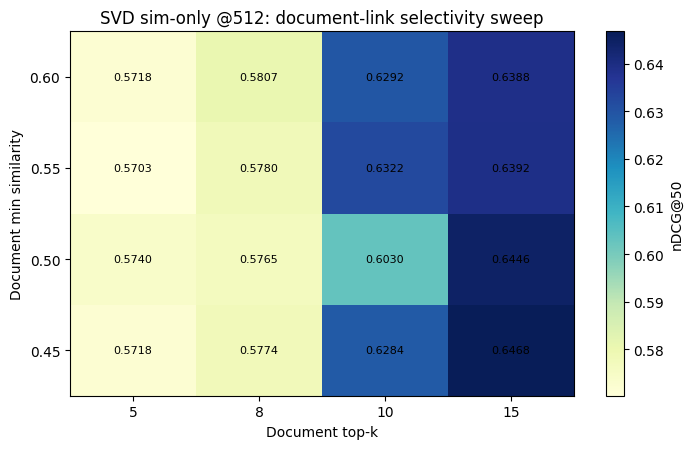

,doc_min_sim,doc_topk,nDCG,Delta,%,MRR,P,R,F1,MAP,linked_docs,n_doc_links
0,0.45,15,0.6468,0.1462,29.2023,0.9042,0.5613,0.4814,0.5183,0.4105,2800,40997
1,0.50,15,0.6446,0.1440,28.7592,0.8708,0.5613,0.4820,0.5186,0.4084,2767,38527
2,0.55,15,0.6392,0.1386,27.6794,0.8714,0.5533,0.4736,0.5104,0.4071,2690,32196
3,0.60,15,0.6388,0.1382,27.6092,0.9364,0.5413,0.4663,0.5010,0.4046,2463,22337
4,0.55,10,0.6322,0.1316,26.2978,0.9394,0.5360,0.4616,0.4960,0.3978,2690,23261
5,0.60,10,0.6292,0.1286,25.6944,0.9378,0.5307,0.4582,0.4918,0.3947,2463,17166
6,0.45,10,0.6284,0.1278,25.5331,0.9074,0.5360,0.4621,0.4963,0.3976,2800,27633
7,0.50,10,0.6030,0.1024,20.4552,0.8733,0.5360,0.4633,0.4970,0.3636,2767,26482
8,0.60,8,0.5807,0.0801,15.9961,0.8460,0.5373,0.4555,0.4930,0.3392,2463,14667
9,0.55,8,0.5780,0.0774,15.4545,0.8738,0.5360,0.4618,0.4961,0.3325,2690,19240



Best row:

                                                                 Method     nDCG    Delta         %      MRR        P        R       F1      MAP  doc_min_sim  doc_topk  used_dim  explained_variance  n_doc_links  linked_docs
dense@100>>KG(SVD sim-only @512,alpha=0.30,docmin=0.45,doctopk=15)->@50 0.646782 0.146186 29.202338 0.904167 0.561333 0.481352 0.518275 0.410514         0.45        15       512            0.772856        40997         2800

Summary:

alpha=0.30
query_min_sim=0.45
query_topk=20
current_doc_min_sim=0.45
current_doc_topk=15
current_ndcg=0.646782
best_doc_min_sim=0.45
best_doc_topk=15
best_ndcg=0.646782
improvement_vs_current=+0.000000
bgegemma_ndcg=0.600791
margin_vs_bgegemma=+0.045991
n_configs=16

Saved: /Users/user/Submissions/BEA-2026/artifacts/svd_simonly_512_doclink_sweep/svd_simonly_512_doclink_sweep_results.csv
Saved: /Users/user/Submissions/BEA-2026/artifacts/svd_simonly_512_doclink_sweep/svd_simonly_512_doclink_sweep_best_row.csv
Saved: /Users/us

In [4]:
rows = []
best_run = None
best_ndcg = -1.0
best_cfg = None

for min_sim in DOC_MIN_SIMS:
    for topk in DOC_TOPKS:
        doc_cfg = filter_doc_links(doc_skills_df, min_sim=min_sim, topk=topk)
        docno2kg, qid2kg, explained, used_dim = build_svd_vectors(doc_cfg, qid_base, SVD_DIM)
        kg = KGReranker(qid2kg, docno2kg, alpha=ALPHA)
        name = f"dense@100>>KG(SVD sim-only @512,alpha={ALPHA:.2f},docmin={min_sim:.2f},doctopk={topk})->@50"
        metrics_df = eval_at_k([
            ("ANN@100->@50", dense_source >> cut50),
            (name, dense_source >> kg >> cut50),
        ], topics, qrels, K_FINAL)
        table_df = to_table1_style(metrics_df, ann_name="ANN@100->@50", k_eval=K_FINAL)
        row = table_df[table_df["Method"] == name].iloc[0].to_dict()
        row["doc_min_sim"] = float(min_sim)
        row["doc_topk"] = int(topk)
        row["used_dim"] = int(used_dim)
        row["explained_variance"] = float(explained)
        row["n_doc_links"] = int(len(doc_cfg))
        row["linked_docs"] = int(doc_cfg["docno"].nunique()) if not doc_cfg.empty else 0
        rows.append(row)
        if float(row["nDCG"]) > best_ndcg:
            best_ndcg = float(row["nDCG"])
            best_cfg = dict(row)
            best_run = (dense_source >> kg >> cut50).transform(topics)
        print(f"min_sim={min_sim:.2f} topk={topk} -> nDCG@50={float(row['nDCG']):.6f}")

results_df = pd.DataFrame(rows).sort_values(["nDCG", "doc_min_sim", "doc_topk"], ascending=[False, True, True]).reset_index(drop=True)
current_row = results_df[(np.isclose(results_df["doc_min_sim"], 0.45)) & (results_df["doc_topk"] == 15)].iloc[0]

results_path = OUT_DIR / "svd_simonly_512_doclink_sweep_results.csv"
best_row_path = OUT_DIR / "svd_simonly_512_doclink_sweep_best_row.csv"
best_run_path = OUT_DIR / "svd_simonly_512_doclink_sweep_best_run.csv"
summary_path = OUT_DIR / "svd_simonly_512_doclink_sweep_summary.txt"
plot_path = OUT_DIR / "svd_simonly_512_doclink_sweep_heatmap.png"

results_df.to_csv(results_path, index=False)
pd.DataFrame([best_cfg]).to_csv(best_row_path, index=False)
best_run.to_csv(best_run_path, index=False)

summary_lines = [
    f"alpha={ALPHA:.2f}",
    f"query_min_sim={QUERY_MIN_SIM:.2f}",
    f"query_topk={QUERY_TOPK}",
    f"current_doc_min_sim=0.45",
    f"current_doc_topk=15",
    f"current_ndcg={float(current_row['nDCG']):.6f}",
    f"best_doc_min_sim={float(best_cfg['doc_min_sim']):.2f}",
    f"best_doc_topk={int(best_cfg['doc_topk'])}",
    f"best_ndcg={float(best_cfg['nDCG']):.6f}",
    f"improvement_vs_current={float(best_cfg['nDCG']) - float(current_row['nDCG']):+.6f}",
    f"bgegemma_ndcg={bge_ndcg:.6f}",
    f"margin_vs_bgegemma={float(best_cfg['nDCG']) - bge_ndcg:+.6f}",
    f"n_configs={len(results_df)}",
]
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

heat = results_df.pivot(index="doc_min_sim", columns="doc_topk", values="nDCG").sort_index(ascending=True)
plt.figure(figsize=(7.2, 4.6))
im = plt.imshow(heat.values, aspect="auto", cmap="YlGnBu", origin="lower")
plt.xticks(range(len(heat.columns)), heat.columns.tolist())
plt.yticks(range(len(heat.index)), [f"{x:.2f}" for x in heat.index.tolist()])
plt.xlabel("Document top-k")
plt.ylabel("Document min similarity")
plt.title("SVD sim-only @512: document-link selectivity sweep")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        plt.text(j, i, f"{heat.values[i, j]:.4f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, label="nDCG@50")
plt.tight_layout()
plt.savefig(plot_path, dpi=160)
plt.show()

display(results_df[["doc_min_sim", "doc_topk", "nDCG", "Delta", "%", "MRR", "P", "R", "F1", "MAP", "linked_docs", "n_doc_links"]].round(4))
print("\nBest row:\n")
print(pd.DataFrame([best_cfg]).to_string(index=False))
print("\nSummary:\n")
print("\n".join(summary_lines))
print("\nSaved:", results_path)
print("Saved:", best_row_path)
print("Saved:", best_run_path)
print("Saved:", summary_path)
print("Saved:", plot_path)
